In [17]:
import sys
from pathlib import Path

import cv2 as cv
from ultralytics import YOLO
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from ecg_scanner.scanner import ECGScanner, ECGScannerConfig
from ecg_digitizer.config import DigitizerConfig  # noqa: E402
from ecg_digitizer.digitizer import ecg_to_csv  # noqa: E402
from ecg_digitizer.utils import create_zip, plot_ecg  # noqa: E402

MODELS_DIR = PROJECT_ROOT / "models"
IMAGES_DIR = PROJECT_ROOT / "datasets" / "samples"
%matplotlib inline

In [18]:
def load_models():
    return YOLO(str(MODELS_DIR / "best.pt")), YOLO(str(MODELS_DIR / "labels.pt"))


model, label_model = load_models()
scanner = ECGScanner()

In [19]:
lead_time = 2.5
sample_frequency = 500
mm_per_sec = 25
pulse_width_mm = 500

pulse_per_sec = pulse_width_mm / mm_per_sec
num_sampling_points = int(lead_time * sample_frequency)

lead_order = [
    "I",
    "aVR",
    "V1",
    "V4",
    "II",
    "aVL",
    "V2",
    "V5",
    "III",
    "aVF",
    "V3",
    "V6",
]

In [20]:
%%script false --no-raise-error

file_path = IMAGES_DIR / "1048962695-0001.png"
csv_name = file_path.stem + ".csv"

config = DigitizerConfig(
    image=file_path,
    csv_name=csv_name,
    pulse_per_sec=pulse_per_sec,
    sample_frequency=sample_frequency,
    num_sampling_points=num_sampling_points,
)

img = cv.imread(config.image)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
results = model(config.image)
result = results[0]

label_boxes = []
if label_model is not None:
    label_results = label_model(config.image)
    for box in label_results[0].boxes:
        lx1, ly1, lx2, ly2 = map(int, box.xyxy[0].tolist())
        label_boxes.append((lx1, ly1, lx2, ly2))

pulse_boxes = [
    box for box in result.boxes if model.names[int(box.cls[0])].lower() == "pulse"
]
if pulse_boxes:
    x1, y1, x2, y2 = map(int, pulse_boxes[0].xyxy[0].tolist())
    pulse_per_mv = (y2 - y1) / 1.0
else:
    pulse_per_mv = 10.0

## Visualização passo a passo do pipeline de digitalização


## Passo 0 - Ler a imagem 

In [21]:

file_path = IMAGES_DIR / "1048962695-0006.png"
csv_name = file_path.stem + ".csv"

config = DigitizerConfig(
    image=file_path,
    csv_name=csv_name,
    pulse_per_sec=pulse_per_sec,
    sample_frequency=sample_frequency,
    num_sampling_points=num_sampling_points,
)


In [22]:

img = cv.imread(config.image)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)


### Passo 1 e 2 — Imagem original e conversão para grayscale


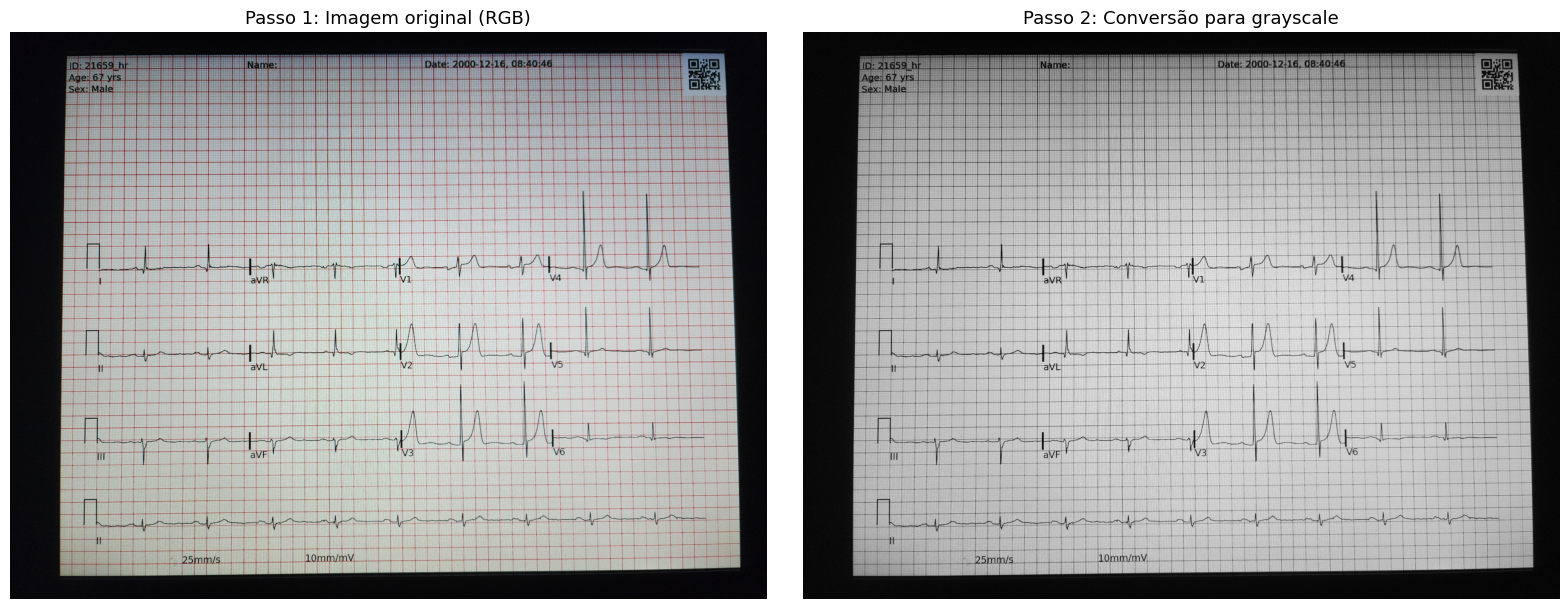

In [23]:
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img_rgb)
axes[0].set_title("Passo 1: Imagem original (RGB)", fontsize=13)
axes[0].axis("off")

axes[1].imshow(img_gray, cmap="gray")
axes[1].set_title("Passo 2: Conversão para grayscale", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Passo 3 — Detecções YOLO: leads e pulso de calibração


In [24]:
results = model(config.image)
result = results[0]


image 1/1 /home/luan-rodrigues/faculdade/ecg-digitization-tool/datasets/samples/1048962695-0006.png: 768x1024 4 pulses, 1 I, 1 aVR, 1 V1, 1 V4, 1 II, 1 aVL, 1 V2, 1 V5, 1 III, 1 aVF, 1 V3, 1 V6, 5.3ms
Speed: 2.9ms preprocess, 5.3ms inference, 0.5ms postprocess per image at shape (1, 3, 768, 1024)


In [25]:
label_boxes = []
if label_model is not None:
    label_results = label_model(config.image)
    for box in label_results[0].boxes:
        lx1, ly1, lx2, ly2 = map(int, box.xyxy[0].tolist())
        label_boxes.append((lx1, ly1, lx2, ly2))

pulse_boxes = [
    box for box in result.boxes if model.names[int(box.cls[0])].lower() == "pulse"
]


image 1/1 /home/luan-rodrigues/faculdade/ecg-digitization-tool/datasets/samples/1048962695-0006.png: 1536x2048 13 labels, 16.4ms
Speed: 8.3ms preprocess, 16.4ms inference, 0.6ms postprocess per image at shape (1, 3, 1536, 2048)


In [ ]:
viz = img_rgb.copy()
boxes = dict()
for box in result.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    cls_id = int(box.cls[0])
    lead_name = model.names[cls_id]
    if lead_name in boxes:
        continue
    boxes[lead_name] = np.array(
        [
            [x1, y1],  # top-left
            [x2, y1],  # top-right
            [x2, y2],  # bottom-right
            [x1, y2],  # bottom-left
        ]
    )
    color = (255, 165, 0) if lead_name.lower() == "pulse" else (0, 200, 0)
    cv.rectangle(viz, (x1, y1), (x2, y2), color, 3)
    cv.putText(viz, lead_name, (x1, y1 - 6), cv.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(viz)
ax.set_title(
    "Passo 3: Detecções YOLO — leads (verde) e pulse de calibração (laranja)",
    fontsize=13,
)
#ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
scanner = ECGScanner(
    v_margin=90, s_margin=60, fill_value=255, dark_percentile=10, s_quantile_offset=0.4
)

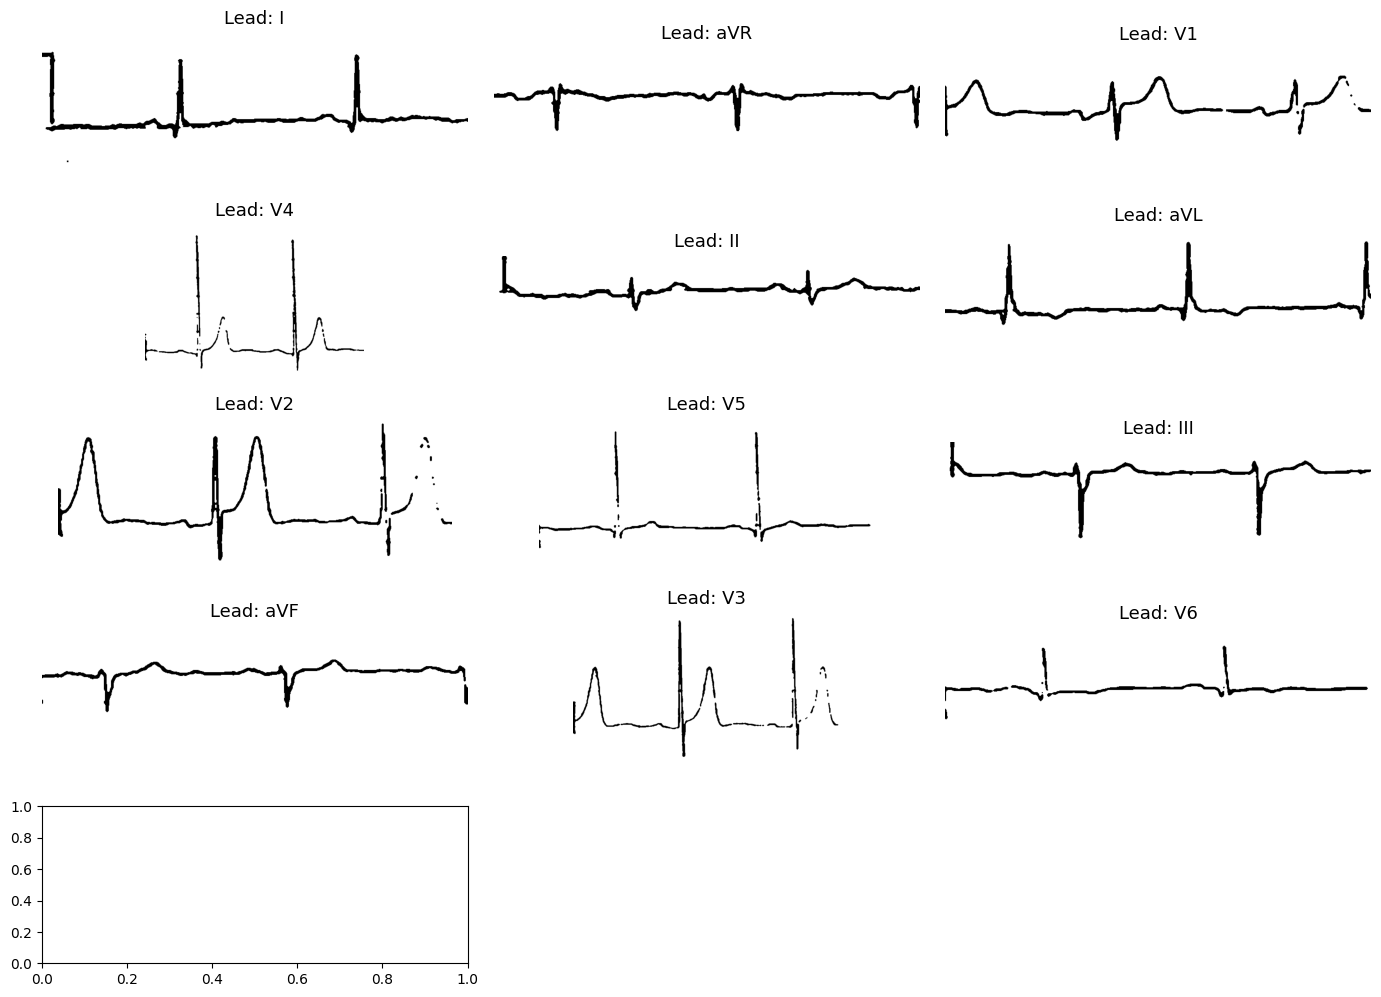

In [ ]:
image_boxes = scanner.scan_yolo(
    image=img, 
    lead_boxes=boxes, 
    label_boxes=label_boxes,
    binarize_method="block_median",
    block_size= 40,
    block_threshold = 25,
    pre_median_k = 3,
    pre_gaussian_k = 5,
    post_median_k = 5,
)
fig, ax = plt.subplots(nrows=(len(lead_order) // 3) + 1, ncols=3, figsize=(14, 10))
ax = ax.flatten()

for i, lead_name in enumerate(lead_order):
    ax[i].imshow(image_boxes[lead_name], cmap="gray")
    ax[i].set_title(
        f"Lead: {lead_name}",
        fontsize=13,
    )
    ax[i].axis("off")
for j in range(len(image_boxes), len(ax)):
    fig.delaxes(ax[j])
plt.tight_layout()
plt.show()

### Passo 6 — Overlay final: curvas sobrepostas na imagem original


In [ ]:
ecg_curves = ecg_to_csv(
    config,
    model,
    label_model,
    binarize_method="block_median",
    block_size=40,
    block_threshold=25,
    pre_median_k=3,
    pre_gaussian_k=5,
    post_median_k=7,
)


image 1/1 /home/luan-rodrigues/faculdade/ecg-digitization-tool/datasets/samples/1048962695-0006.png: 768x1024 4 pulses, 1 I, 1 aVR, 1 V1, 1 V4, 1 II, 1 aVL, 1 V2, 1 V5, 1 III, 1 aVF, 1 V3, 1 V6, 5.6ms
Speed: 2.7ms preprocess, 5.6ms inference, 0.6ms postprocess per image at shape (1, 3, 768, 1024)

image 1/1 /home/luan-rodrigues/faculdade/ecg-digitization-tool/datasets/samples/1048962695-0006.png: 1536x2048 13 labels, 16.4ms
Speed: 7.8ms preprocess, 16.4ms inference, 0.6ms postprocess per image at shape (1, 3, 1536, 2048)


In [ ]:
ecg_curves

,i,avr,v1,v4,ii,avl,v2,v5,iii,avf,v3,v6
0.000000,0.712644,-0.011494,0.229885,0.310345,0.350575,-0.011494,0.350575,0.017241,0.327586,-0.051724,0.287356,0.005747
0.000801,0.712644,-0.011448,0.219817,0.314807,0.350575,-0.011494,0.350539,0.018271,0.327572,-0.051679,0.287372,0.005911
0.001601,0.712644,-0.011524,0.227296,0.307153,0.350574,-0.011494,0.350601,0.015883,0.327599,-0.051756,0.287344,0.005612
0.002402,0.712644,-0.011530,0.223633,0.303038,0.350575,-0.011494,0.350596,0.011958,0.327591,-0.051754,0.287348,0.005674
0.003203,0.712644,-0.011347,0.184573,0.312623,0.350576,-0.011494,0.349681,0.008128,0.327531,-0.051569,0.287414,0.006367
...,...,...,...,...,...,...,...,...,...,...,...,...
0.996797,0.002317,0.054486,-0.008701,-0.011494,0.017868,0.229217,-0.034483,1.488510,0.017241,-0.166591,1.811382,0.648064
0.997598,0.005990,0.058396,-0.011928,-0.011494,0.017189,0.225184,-0.034483,1.488505,0.017241,-0.166773,1.810189,0.649585
0.998399,0.006265,0.061915,-0.011937,-0.011494,0.017100,0.180475,-0.034483,1.488505,0.017241,-0.170307,1.810124,0.649723
0.999199,0.005137,0.065480,-0.010860,-0.011494,0.017402,0.138144,-0.034483,1.488507,0.017241,-0.175578,1.810629,0.649065


/tmp/ipykernel_29281/3718608752.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


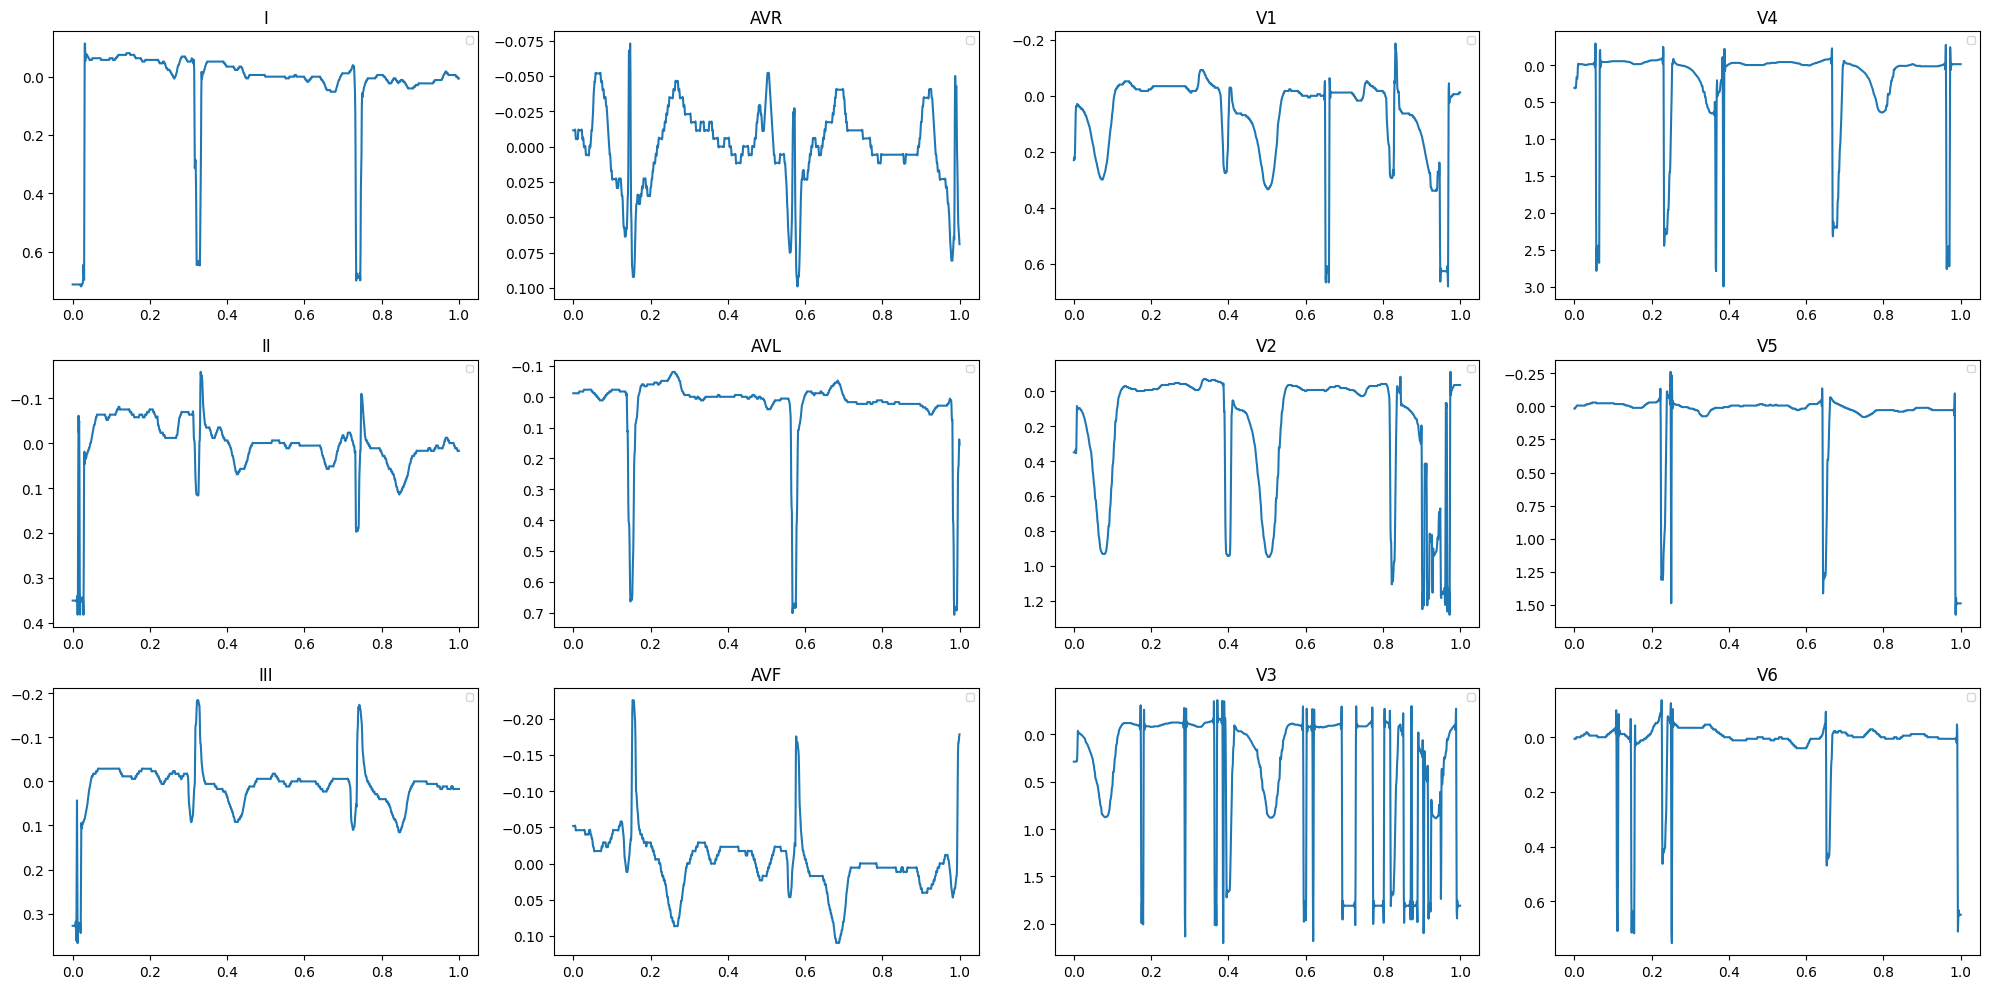

In [ ]:
                                                                            
n_rows, n_cols = 3, 4                                                         
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))                    
axes = axes.flatten()                                                         
                                                        
for ax, c in zip(axes, ecg_curves.columns):                  
    ax.plot(ecg_curves[c])                  
    ax.set_title(c.upper())                                           
    ax.invert_yaxis()
    ax.legend(fontsize=7)                                                     
                                                                            
for ax in axes[len(ecg_curves):]:
    ax.set_visible(False)                                                     
                                                                            
plt.tight_layout()
plt.show()                         

In [ ]:
v4 = df["v4"]["yseg"]
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(v4)

KeyError: 'yseg'

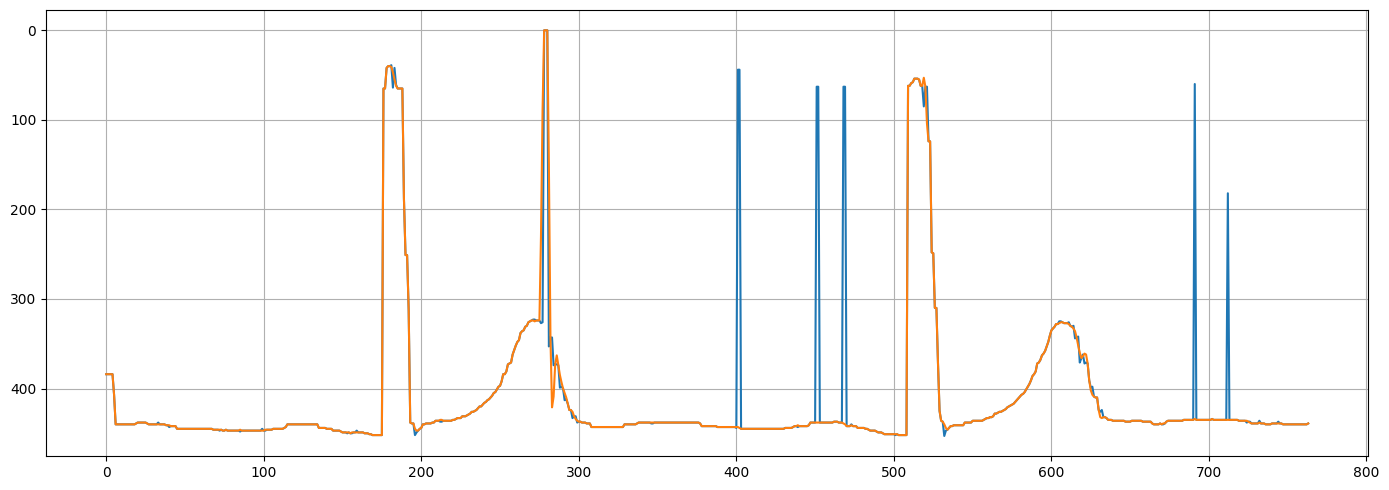

In [ ]:
with pd.option_context("display.max_rows",None):
    display(pd.Series(v4))

0      384
1      384
2      384
3      384
4      384
5      407
6      440
7      440
8      440
9      440
10     440
11     440
12     440
13     440
14     440
15     440
16     440
17     440
18     440
19     439
20     438
21     438
22     438
23     438
24     438
25     438
26     439
27     440
28     440
29     440
30     440
31     440
32     440
33     438
34     440
35     440
36     440
37     440
38     441
39     441
40     443
41     442
42     442
43     442
44     442
45     445
46     445
47     445
48     445
49     445
50     445
51     445
52     445
53     445
54     445
55     445
56     445
57     445
58     445
59     445
60     445
61     445
62     445
63     445
64     445
65     445
66     445
67     445
68     446
69     446
70     446
71     446
72     447
73     446
74     447
75     447
76     446
77     447
78     447
79     447
80     447
81     447
82     447
83     447
84     447
85     448
86     447
87     447
88     447
89     447
90     447

0      384
1      384
2      384
3      384
4      384
      ... 
759    440
760    440
761    440
762    440
763    439
Length: 764, dtype: int64

In [ ]:
plt.plot(data["v4"]["yseg"]  )

KeyError: 'v4'

<Axes: >

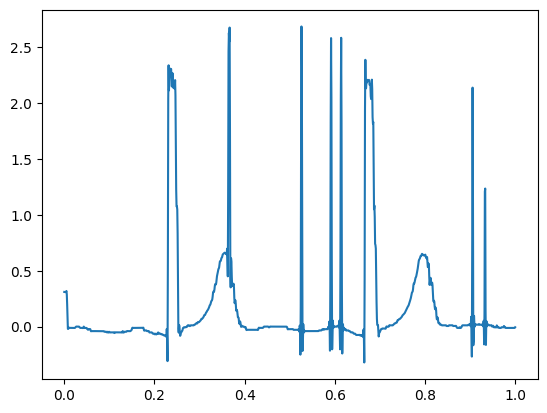

In [ ]:
df["v4"].plot(kind="line")